In [77]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import NearestNeighbors 

# Task 1

In [56]:
insurance_df = pd.read_csv('insurance.csv')
print(insurance_df.head())
print(f'\nShape: {insurance_df.shape}\n')
print(insurance_df[['age','bmi','charges']].describe())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Shape: (1338, 7)

               age          bmi       charges
count  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397  13270.422265
std      14.049960     6.098187  12110.011237
min      18.000000    15.960000   1121.873900
25%      27.000000    26.296250   4740.287150
50%      39.000000    30.400000   9382.033000
75%      51.000000    34.693750  16639.912515
max      64.000000    53.130000  63770.428010


1. Charges has the largest range, approximately 50,000
2. Age and BMI are on the most similar scale.
3. The distance between points will be much larger for charges than anything else, so that distance will dominate the algorith and mitigate most distances in the other two columns.

# Task 2

C:\Users\macgy\AppData\Local\Temp\ipykernel_30956\1333981148.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


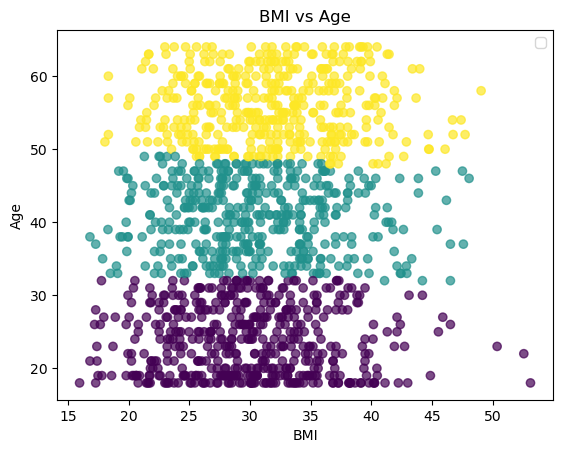

In [57]:
X = insurance_df[['age','bmi']]

km = KMeans(n_clusters=3)
insurance_df['cluster'] = km.fit_predict(X)

plt.scatter(insurance_df['bmi'], 
            insurance_df['age'], 
            c=insurance_df['cluster'],
            alpha=0.7)
plt.xlabel('BMI')
plt.ylabel('Age')
plt.title('BMI vs Age')
plt.legend()

The clusters look pretty arbitrary, just based on age. Seems like the cutoffs between clusters are approx. 30 years old and 50 years old.

# Task 3

C:\Users\macgy\AppData\Local\Temp\ipykernel_30956\3728943955.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


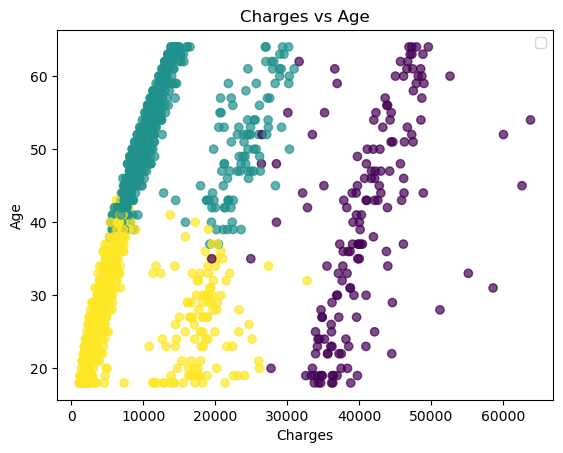

In [58]:
ss = StandardScaler()
X = insurance_df[['age','bmi','charges']]
X_scaled = ss.fit_transform(X)

km_scaled = KMeans(n_clusters=3)
insurance_df['cluster_scaled'] = km_scaled.fit_predict(X_scaled)

plt.scatter(insurance_df['charges'], 
            insurance_df['age'], 
            c=insurance_df['cluster_scaled'],
            alpha=0.7)
plt.xlabel('Charges')
plt.ylabel('Age')
plt.title('Charges vs Age')
plt.legend()

There are much more distinct patters in the scaled plot. There still seems to be a pretty strong cutoff at 40 years old for the two groups with low charges. Scaling is important because the distance between points will be much larger for charges than anything else, so that distance will dominate the algorith and mitigate most distances in the other two columns. Scaling aleviates this problem.

# Task 4

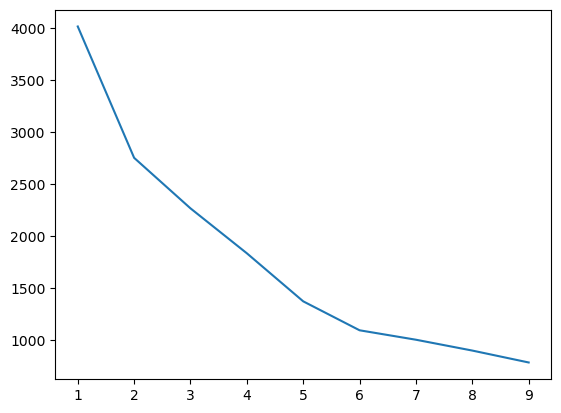

In [59]:
inertia = []
for k in range(1,10):
    km_scaled = KMeans(n_clusters=k)
    km_scaled.fit(X_scaled)
    inertia.append(km_scaled.inertia_)

plt.plot(range(1,10), inertia)

The elbow appears at k=4. This means that the first time we get a meaningful number of clusters is when we tell the model to look for 4 clusters.

# Task 5

In [60]:
silhouette = []

for k in range(1,10):
    kmscaled = KMeans(n_clusters=k)
    km_scaled.fit(X_scaled)
    silhouette.append(silhouette_score(X_scaled, km_scaled.labels_))

silhouette_df = pd.DataFrame(silhouette)

silhouette_df

,0
0,0.319312
1,0.322821
2,0.323481
3,0.330878
4,0.313433
5,0.291997
6,0.314000
7,0.320074
8,0.293306


Silhouette score measures how close each dot is to its centroid and the distance from the next one. A higher score means its better and in the correct category. 

# Task 6

In [61]:
ss = StandardScaler()
X = insurance_df[['age','bmi','charges']]
X_scaled = ss.fit_transform(X)

km_scaled = KMeans(n_clusters=4)
insurance_df['cluster_scaled'] = km_scaled.fit_predict(X_scaled)
insurance_df.groupby('cluster_scaled')[['age', 'bmi', 'charges']].mean()

,age,bmi,charges
cluster_scaled,,,
0,39.743902,35.242287,40431.620294
1,32.051471,36.874890,5752.750548
2,28.742152,25.779439,7432.852678
3,53.517544,30.088355,13695.699164


cluster 0: older, medium charges, low bmi
cluster 1: middle age/older, low charges, high bmi (close in age to 0 but far apart in bmi 
and charges)
cluster 2: middle age, high charges, high bmi
cluster 3: younger, low charges, low bmi



The groups indicate that we are likely missing a feature (smoking) for it to make sense intuitively. 


# Advanced Tasks

# Task 7

In [62]:
bike_df = pd.read_csv("bike.csv")
bike_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [63]:
ss = StandardScaler()
X = bike_df[['temp', 'hum', 'windspeed', 'casual', 'registered']]
X_scaled = ss.fit_transform(X)

km_scaled = KMeans(n_clusters=3)
bike_df['cluster_scaled'] = km_scaled.fit_predict(X_scaled)

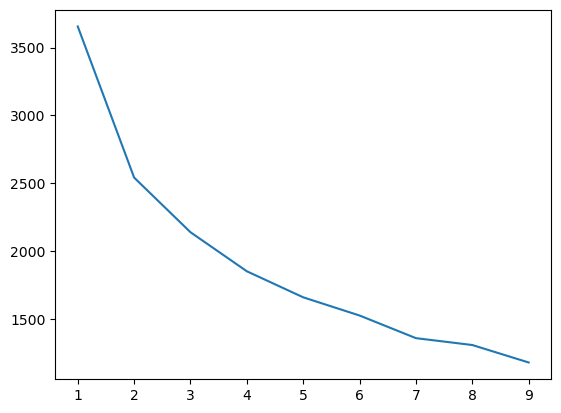

In [64]:
inertia = []
for k in range(1,10):
    km_scaled = KMeans(n_clusters=k)
    km_scaled.fit(X_scaled)
    inertia.append(km_scaled.inertia_)

plt.plot(range(1,10), inertia)

In [65]:
silhouette = []

for k in range(1,10):
    kmscaled = KMeans(n_clusters=k)
    km_scaled.fit(X_scaled)
    silhouette.append(silhouette_score(X_scaled, km_scaled.labels_))

silhouette_df = pd.DataFrame(silhouette)

silhouette_df

,0
0,0.216806
1,0.225445
2,0.215209
3,0.216562
4,0.213743
5,0.218121
6,0.222481
7,0.215059
8,0.207284


In [66]:
ss = StandardScaler()
X = bike_df[['temp', 'hum', 'windspeed', 'casual', 'registered']]
X_scaled = ss.fit_transform(X)

km_scaled = KMeans(n_clusters=3)
bike_df['cluster_scaled'] = km_scaled.fit_predict(X_scaled)

bike_df.groupby('cluster_scaled')[['temp', 'hum', 'windspeed', 'casual', 'registered']].mean()

,temp,hum,windspeed,casual,registered
cluster_scaled,,,,,
0,0.420858,0.768473,0.172470,465.941463,2804.087805
1,0.320265,0.504682,0.244212,435.034826,2817.422886
2,0.650699,0.615424,0.168622,1344.790769,4712.375385


cluster 0: higher temp, higher casual and registered w/ lower windspeed
cluster 1: low temp, lower casual and registered w/ lower windspeed
cluster 2: middle temp, lower casual and registered w/ higher windsepped


Text(0.5, 1.0, 'K-Means clusters (k=3)')

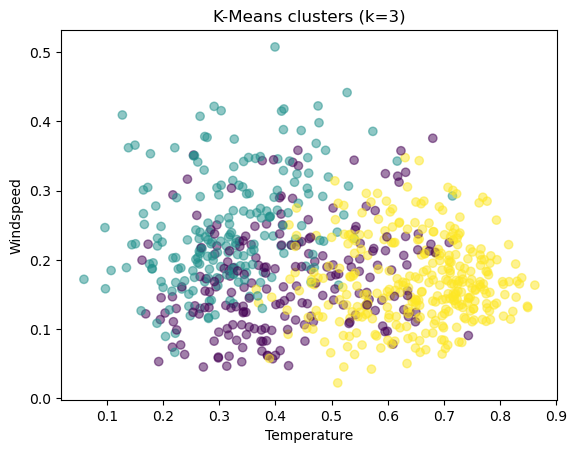

In [68]:
plt.scatter(bike_df['temp'], bike_df['windspeed'],
            c=bike_df['cluster_scaled'], cmap='viridis', alpha=0.5
            )
plt.xlabel('Temperature')
plt.ylabel("Windspeed")
plt.title('K-Means clusters (k=3)')

# Task 8

In [76]:
X = insurance_df[['age','bmi','charges']]
X_scaled = ss.fit_transform(X)

db = DBSCAN(eps=0.5, min_samples=5)
db.fit(X_scaled)

insurance_df['clusters_dbscan'] = db.labels_

print('groups minus noise',insurance_df['clusters_dbscan'].nunique() -1)
print('number of noise points',(insurance_df['clusters_dbscan'] == -1).sum())



groups minus noise 2
number of noise points 51


2 groups were found and 51 points were found as noise.

# Extra Credit